C:\Users\tejas\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.4658 - loss: 1.8220 - val_accuracy: 0.6825 - val_loss: 0.9924
Epoch 2/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6953 - loss: 0.9622 - val_accuracy: 0.7875 - val_loss: 0.6970
Epoch 3/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7503 - loss: 0.7868 - val_accuracy: 0.8213 - val_loss: 0.5830
Epoch 4/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7841 - loss: 0.6856 - val_accuracy: 0.8375 - val_loss: 0.5155
Epoch 5/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8051 - loss: 0.6156 - val_accuracy: 0.8675 - val_loss: 0.4416
Epoch 6/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8226 - loss: 0.5607 - val_accuracy: 0.8769 - val_loss: 0.4112
Epoch 7/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8354 - loss: 0.5162 - val_accuracy: 0.8875 - val_loss: 0.3595
Epoch 8/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8494 - loss: 0.4797 - val_accuracy: 0.

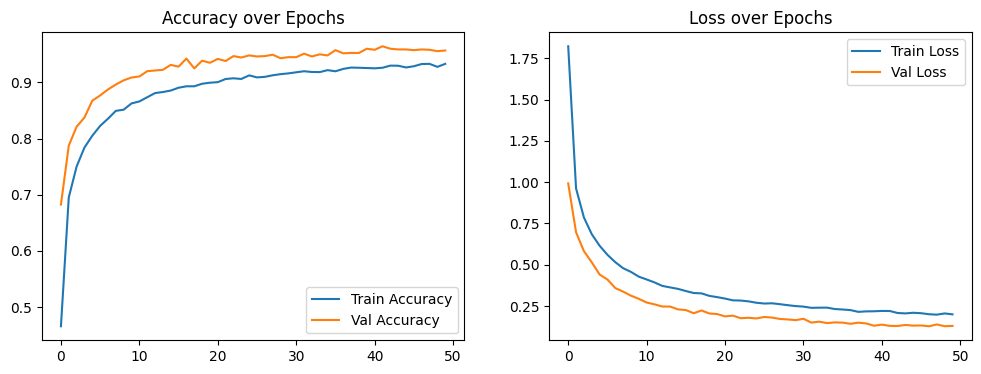

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import io



# In a real scenario, use: df = pd.read_csv('letter-recognition.data', header=None)
# Using the provided snippet as a base:
column_names = ['letter', 'xbox', 'ybox', 'width', 'height', 'onpix', 'xbar', 
                'ybar', 'x2bar', 'y2bar', 'xybar', 'x2ybar', 'xy2bar', 
                'xedge', 'xedgey', 'yedge', 'yedgex']

# For this script, we assume the data is saved in 'ocr_data.csv'
# Replace the line below with your actual filepath
df = pd.read_csv("C:/Users/tejas/Downloads/letter+recognitiondataset/letter-recognition.data", header=None, names=column_names)

# 2. PREPROCESSING
# Separate features (X) and target (y)
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

# Encode letters (A-Z) to integers (0-25)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Standardize the features (Mean=0, Variance=1) - Critical for Neural Networks
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

# 3. BUILD THE DEEP NEURAL NETWORK
model = models.Sequential([
    # Input layer and first hidden layer
    layers.Dense(128, activation='relu', input_shape=(16,)),
    layers.Dropout(0.2), # Dropout to prevent overfitting
    
    # Second hidden layer
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.1),
    
    # Third hidden layer
    layers.Dense(32, activation='relu'),
    
    # Output layer: 26 neurons (one for each letter), Softmax for probability distribution
    layers.Dense(26, activation='softmax')
])

# 4. COMPILE THE MODEL
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Used when labels are integers
    metrics=['accuracy']
)

# 5. TRAIN THE MODEL
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# 6. EVALUATE THE MODEL
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# 7. PREDICTIONS & ANALYSIS
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# 8. VISUALIZE TRAINING PROGRESS
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.show()

In [2]:
# Example: A new raw data row (16 features)
raw_data = np.array([[4, 11, 6, 8, 6, 10, 6, 2, 6, 10, 3, 7, 3, 7, 3, 9]])

# STEP A: Scale the data (Crucial!)
scaled_data = scaler.transform(raw_data)

# STEP B: Predict
prediction = model.predict(scaled_data)

# STEP C: Get the letter
predicted_letter = label_encoder.inverse_transform([np.argmax(prediction)])

print(f"The model predicts this letter is: {predicted_letter[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
The model predicts this letter is: D


In [15]:
prediction = model.predict(X_test)

for i in range(100):
    predicted_letter = label_encoder.inverse_transform([np.argmax(prediction[i])])
    print(f"The model predicts this letter is: {predicted_letter[0]}")


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
The model predicts this letter is: T
The model predicts this letter is: L
The model predicts this letter is: A
The model predicts this letter is: E
The model predicts this letter is: Q
The model predicts this letter is: E
The model predicts this letter is: O
The model predicts this letter is: Q
The model predicts this letter is: G
The model predicts this letter is: O
The model predicts this letter is: B
The model predicts this letter is: P
The model predicts this letter is: V
The model predicts this letter is: Q
The model predicts this letter is: M
The model predicts this letter is: V
The model predicts this letter is: B
The model predicts this letter is: K
The model predicts this letter is: S
The model predicts this letter is: D
The model predicts this letter is: B
The model predicts this letter is: P
The model predicts this letter is: Q
The model predicts this letter is: O
The model predicts this letter is: W
The model predicts this letter is:

In [13]:
X_test

4000
